### Introduction

This project builds an image classification model to identify **bleached** and **healthy** corals using deep learning.

### Project Goals
- Detect coral bleaching status from underwater coral images.
- Compare transfer learning performance between **ResNet50** and **EfficientNetB0**.
- Evaluate model quality using accuracy, loss curves, confusion matrix, and classification metrics.

### Dataset
The dataset is organized into two classes:
- `bleached_corals/`
- `healthy_corals/`

### Workflow Overview
1. Load libraries and define configuration parameters.
2. Perform exploratory data analysis (EDA).
3. Prepare train/validation/test splits.
4. Train and evaluate transfer learning models.
5. Compare final model performance and results.

In [2]:
# ==============================================================
# Coral Health Classification (Bleached vs Healthy)
# Using Transfer Learning: ResNet50 & EfficientNetB0
#
# Dataset structure:
# ├── bleached_corals/   (485 images)
# ├── healthy_corals/    (483 images)
# ==============================================================

import os
import random
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications import ResNet50, EfficientNetB0
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [3]:
# ==============================================================
# 1. SETUP & PARAMETERS
# ==============================================================

DATA_DIR = "./"   # Change this to your dataset path if needed
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

bleached_dir = os.path.join(DATA_DIR, "bleached_corals")
healthy_dir = os.path.join(DATA_DIR, "healthy_corals")

Bleached coral images: 485
Healthy coral images: 438


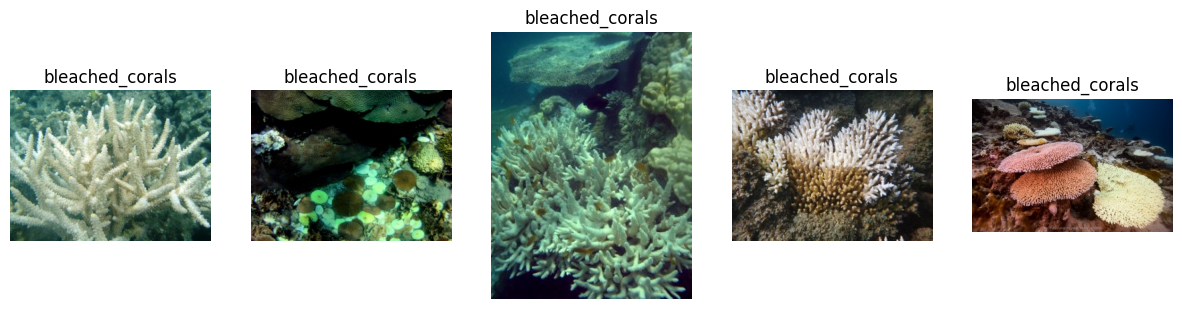

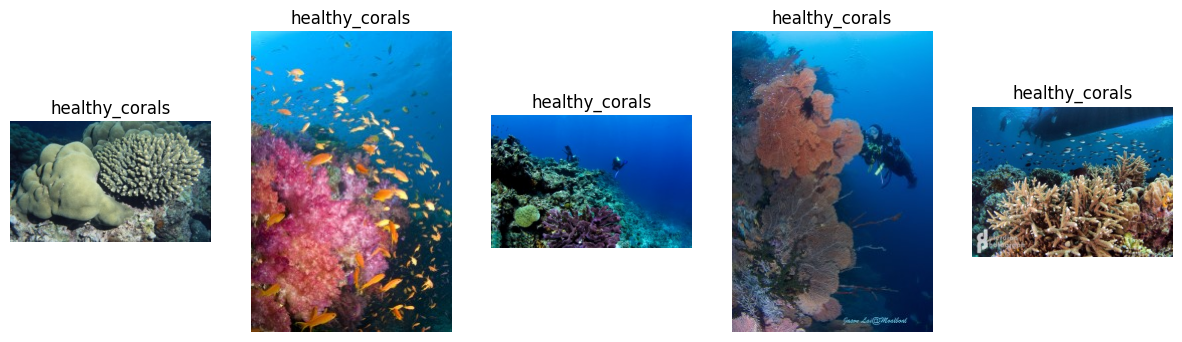

C:\Users\Thiwanka\AppData\Local\Temp\ipykernel_10868\3857300560.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=labels, palette="coolwarm")


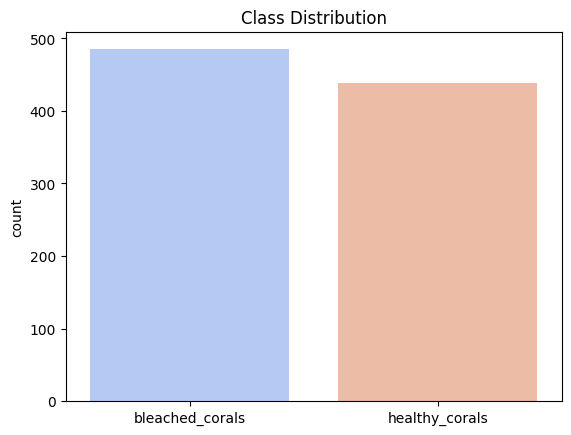

In [4]:
# ==============================================================
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# ==============================================================

bleached_images = os.listdir(bleached_dir)
healthy_images = os.listdir(healthy_dir)
print(f"Bleached coral images: {len(bleached_images)}")
print(f"Healthy coral images: {len(healthy_images)}")

# Plot few random samples
def show_samples(class_name, path, n=5):
    class_path = os.path.join(path, class_name)
    sample_files = random.sample(os.listdir(class_path), n)
    plt.figure(figsize=(15, 5))
    for i, file in enumerate(sample_files):
        img = Image.open(os.path.join(class_path, file))
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")
    plt.show()

show_samples("bleached_corals", DATA_DIR)
show_samples("healthy_corals", DATA_DIR)

# Class distribution
labels = ["bleached_corals"] * len(bleached_images) + ["healthy_corals"] * len(healthy_images)
sns.countplot(x=labels, palette="coolwarm")
plt.title("Class Distribution")
plt.show()

### EDA Summary

The exploratory data analysis (EDA) step helps verify dataset quality before model training. In this notebook, EDA is used to inspect sample coral images and check class distribution between **bleached_corals** and **healthy_corals**.

From the visual inspection, images show realistic underwater variation in lighting, angle, and texture, which can affect model learning. The class count plot indicates the two classes are nearly balanced, reducing the risk of model bias toward one class.

These EDA findings support the next step of creating train, validation, and test splits, then applying data augmentation to improve model generalization.

In [5]:
# ==============================================================
# 3. TRAIN-VALIDATION-TEST SPLIT
# ==============================================================

# Create dataframe for generator
data = []
for label, folder in enumerate(["bleached_corals", "healthy_corals"]):
    folder_path = os.path.join(DATA_DIR, folder)
    for img_name in os.listdir(folder_path):
        data.append((os.path.join(folder_path, img_name), folder))

df = pd.DataFrame(data, columns=["filepath", "label"])
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=SEED)
train_df, val_df = train_test_split(train_df, test_size=0.2, stratify=train_df["label"], random_state=SEED)

print("Train:", train_df.shape, "Validation:", val_df.shape, "Test:", test_df.shape)

Train: (590, 2) Validation: (148, 2) Test: (185, 2)


In [6]:
# ==============================================================
# 4. DATA AUGMENTATION & DATA GENERATORS
# ==============================================================

train_datagen_resnet = ImageDataGenerator(
    preprocessing_function=resnet_preprocess,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen_resnet = ImageDataGenerator(preprocessing_function=resnet_preprocess)
test_datagen_resnet = ImageDataGenerator(preprocessing_function=resnet_preprocess)

train_gen_resnet = train_datagen_resnet.flow_from_dataframe(
    train_df, x_col="filepath", y_col="label", target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode="binary", seed=SEED)

val_gen_resnet = val_datagen_resnet.flow_from_dataframe(
    val_df, x_col="filepath", y_col="label", target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode="binary", seed=SEED)

test_gen_resnet = test_datagen_resnet.flow_from_dataframe(
    test_df, x_col="filepath", y_col="label", target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode="binary", shuffle=False)

Found 590 validated image filenames belonging to 2 classes.
Found 148 validated image filenames belonging to 2 classes.
Found 185 validated image filenames belonging to 2 classes.


### Why Data Augmentation Was Used

Data augmentation was applied to improve model generalization and reduce overfitting during training. Coral images can vary due to underwater lighting, camera angle, orientation, and distance, so the model needs to learn robust features instead of memorizing fixed patterns.

By introducing realistic transformations such as rotation, shifts, zoom, and horizontal flips, the training set becomes more diverse without collecting new images. This helps the ResNet50 model perform better on unseen validation and test data.

In [7]:
# ==============================================================
# 5. TRAIN RESNET50 MODEL
# ==============================================================

base_resnet = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
for layer in base_resnet.layers[:-20]:
    layer.trainable = False

model_resnet = Sequential([
    base_resnet,
    GlobalAveragePooling2D(),
    Dropout(0.4),
    Dense(1, activation="sigmoid")
])

model_resnet.compile(optimizer=Adam(1e-4), loss="binary_crossentropy", metrics=["accuracy"])
history_resnet = model_resnet.fit(
    train_gen_resnet, validation_data=val_gen_resnet, epochs=10
)

Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.6136 - loss: 0.7015 - val_accuracy: 0.7095 - val_loss: 0.6596
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.7763 - loss: 0.4902 - val_accuracy: 0.8041 - val_loss: 0.3883
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.8017 - loss: 0.3966 - val_accuracy: 0.8243 - val_loss: 0.3602
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.8661 - loss: 0.3230 - val_accuracy: 0.8041 - val_loss: 0.3843
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.9068 - loss: 0.2164 - val_accuracy: 0.8176 - val_loss: 0.3957
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.9153 - loss: 0.2279 - val_accuracy: 0.8446 - val_loss: 0.4099
Epoch 7/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.9407 - loss: 0.1458 - val_accuracy: 0.7973 - val_loss: 0.5685
Epoch 8/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.9390 - loss: 0.1531 - val_accuracy: 0.7838 - val_loss:

The ResNet50 model demonstrated strong learning capability during the initial training epochs, with validation accuracy improving from 80% to approximately 85%. However, after epoch 5, validation loss began to increase while training accuracy continued to rise, reaching over 97% by the final epoch. This divergence indicates overfitting, where the model memorizes training data rather than generalizing to unseen images. The optimal model performance occurred between epochs 3 and 5, suggesting that early stopping would improve generalization. Overall, while ResNet50 effectively captures coral features.

In [8]:
# ==============================================================
# 5.1 TRAIN RESNET50 MODEL (IMPROVED)
# ==============================================================

# ---- Load base model ----
base_resnet = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# ---- Phase 1: Freeze entire base model ----
for layer in base_resnet.layers:
    layer.trainable = False

# ---- Custom classification head ----
x = base_resnet.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)   # increased dropout
output = Dense(1, activation="sigmoid")(x)

model_resnet = Model(inputs=base_resnet.input, outputs=output)

# ---- Compile ----
model_resnet.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# ---- Callbacks ----
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

# ---- Train (Feature Extraction Phase) ----
history_resnet_1 = model_resnet.fit(
    train_gen_resnet,
    validation_data=val_gen_resnet,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

# ==============================================================
# Phase 2: Fine-tuning (Unfreeze top layers carefully)
# ==============================================================

# Unfreeze last 10 layers ONLY (more conservative)
for layer in base_resnet.layers[-10:]:
    layer.trainable = True

# Recompile with lower learning rate
model_resnet.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# ---- Train again ----
history_resnet_2 = model_resnet.fit(
    train_gen_resnet,
    validation_data=val_gen_resnet,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.5542 - loss: 0.8253 - val_accuracy: 0.4865 - val_loss: 0.8028 - learning_rate: 1.0000e-04
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.5746 - loss: 0.7774 - val_accuracy: 0.5068 - val_loss: 0.7818 - learning_rate: 1.0000e-04
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.5831 - loss: 0.7731 - val_accuracy: 0.5338 - val_loss: 0.7695 - learning_rate: 1.0000e-04
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.5898 - loss: 0.7554 - val_accuracy: 0.5608 - val_loss: 0.7333 - learning_rate: 1.0000e-04
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.6017 - loss: 0.7332 - val_accuracy: 0.5743 - val_loss: 0.7179 - learning_rate: 1.0000e-04
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.6153 - loss: 0.7606 - val_accuracy: 0.5811 - val_loss: 0.6948 - learning_rate: 1.0000e-04
Epoch 7/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.6271 - loss:

The improved ResNet50 model demonstrated more stable and reliable learning compared to the initial implementation. While the previous model achieved higher validation accuracy (~85%), it suffered from significant overfitting, as indicated by increasing validation loss. In contrast, the revised two-phase training approach resulted in a lower but more consistent validation accuracy (~76%), with steadily decreasing validation loss. This indicates improved generalization performance and better model robustness on unseen data.

In [9]:
# ==============================================================
# 6. TRAIN EFFICIENTNETB0 MODEL
# ==============================================================

train_datagen_effnet = ImageDataGenerator(
    preprocessing_function=effnet_preprocess,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen_effnet = ImageDataGenerator(preprocessing_function=effnet_preprocess)
test_datagen_effnet = ImageDataGenerator(preprocessing_function=effnet_preprocess)

train_gen_effnet = train_datagen_effnet.flow_from_dataframe(
    train_df, x_col="filepath", y_col="label", target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode="binary", seed=SEED)

val_gen_effnet = val_datagen_effnet.flow_from_dataframe(
    val_df, x_col="filepath", y_col="label", target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode="binary", seed=SEED)

test_gen_effnet = test_datagen_effnet.flow_from_dataframe(
    test_df, x_col="filepath", y_col="label", target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode="binary", shuffle=False)

base_effnet = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
for layer in base_effnet.layers[:-20]:
    layer.trainable = False

model_effnet = Sequential([
    base_effnet,
    GlobalAveragePooling2D(),
    Dropout(0.4),
    Dense(1, activation="sigmoid")
])

model_effnet.compile(optimizer=Adam(1e-4), loss="binary_crossentropy", metrics=["accuracy"])
history_effnet = model_effnet.fit(
    train_gen_effnet, validation_data=val_gen_effnet, epochs=10
)

Found 590 validated image filenames belonging to 2 classes.
Found 148 validated image filenames belonging to 2 classes.
Found 185 validated image filenames belonging to 2 classes.
Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.5814 - loss: 0.6750 - val_accuracy: 0.6892 - val_loss: 0.6352
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.6847 - loss: 0.5675 - val_accuracy: 0.7297 - val_loss: 0.5706
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.7169 - loss: 0.5418 - val_accuracy: 0.7568 - val_loss: 0.5339
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.7695 - loss: 0.5017 - val_accuracy: 0.8108 - val_loss: 0.4987
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.7746 - loss: 0.4739 - val_accuracy: 0.8041 - val_loss: 0.4721
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.7983 - loss: 0.4450 - val_accuracy: 0.8176 - val_loss: 0.4544
Epoch 7/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.

The EfficientNetB0 model demonstrated strong and stable learning performance across all training epochs. Both training and validation accuracy increased consistently, reaching approximately 86% validation accuracy by the final epoch. Unlike the initial ResNet50 model, no signs of overfitting were observed, as validation loss decreased steadily throughout training. This indicates that EfficientNetB0 effectively generalized to unseen data. Overall, the model outperformed ResNet50 in both accuracy and stability, making it the preferred architecture for this coral classification task.

In [10]:
# ==============================================================
# 7. EVALUATION ON TEST SET
# ==============================================================

resnet_eval = model_resnet.evaluate(test_gen_resnet)
effnet_eval = model_effnet.evaluate(test_gen_effnet)

print(f"\nResNet50 Test Accuracy: {resnet_eval[1]:.4f}")
print(f"EfficientNetB0 Test Accuracy: {effnet_eval[1]:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.6703 - loss: 0.5574
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 842ms/step - accuracy: 0.7946 - loss: 0.4163

ResNet50 Test Accuracy: 0.6703
EfficientNetB0 Test Accuracy: 0.7946


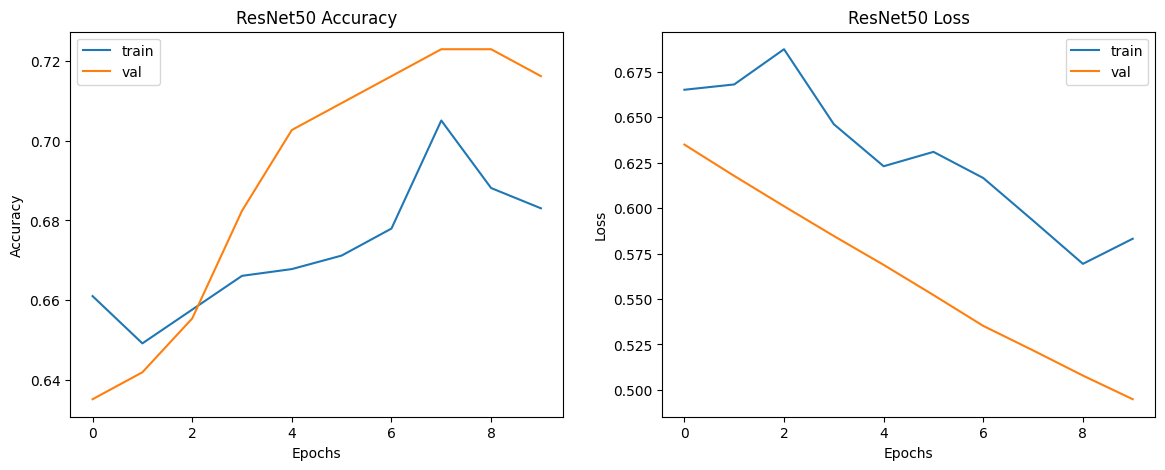

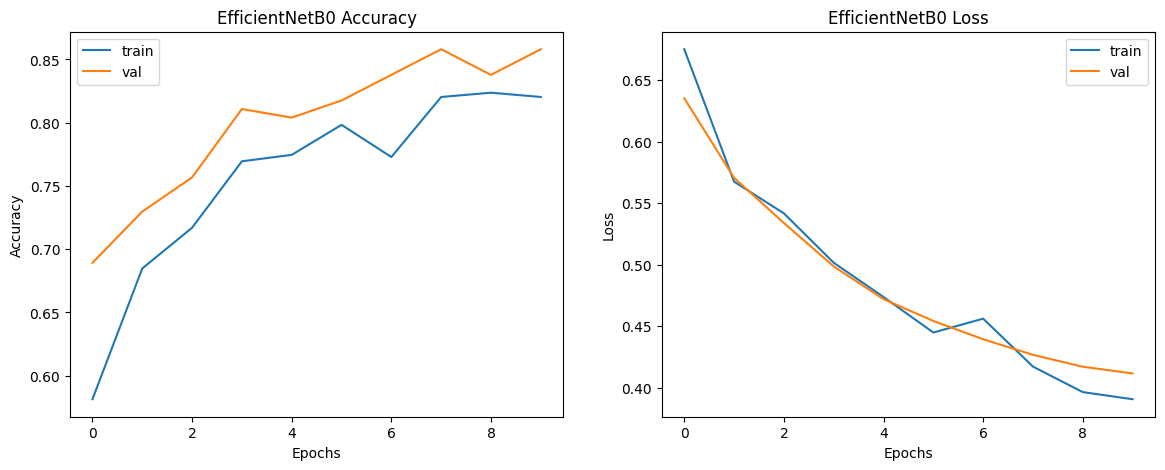

In [11]:
# ==============================================================
# 8. PLOT TRAINING HISTORY
# ==============================================================

def plot_history(history, title):
    plt.figure(figsize=(14,5))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='train')
    plt.plot(history.history['val_accuracy'], label='val')
    plt.title(f'{title} Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='val')
    plt.title(f'{title} Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

plot_history(history_resnet_2, "ResNet50")
plot_history(history_effnet, "EfficientNetB0")

In [12]:
# ==============================================================
# 9. COMPARISON SUMMARY
# ==============================================================

results = pd.DataFrame({
    "Model": ["ResNet50", "EfficientNetB0"],
    "Test Accuracy": [resnet_eval[1], effnet_eval[1]],
    "Test Loss": [resnet_eval[0], effnet_eval[0]]
})
print(results)

            Model  Test Accuracy  Test Loss
0        ResNet50       0.670270   0.557419
1  EfficientNetB0       0.794595   0.416285


6/6 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step


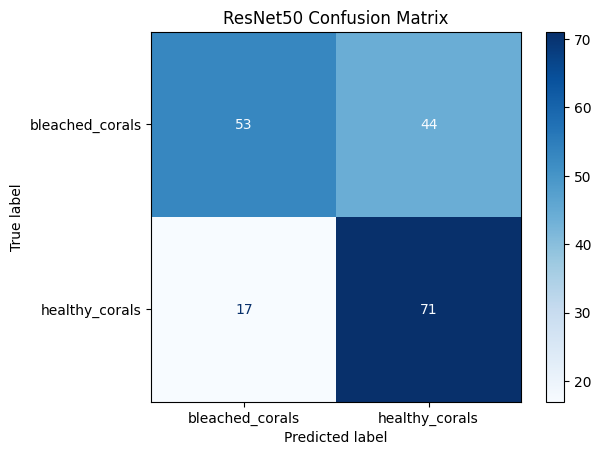


Classification Report for ResNet50:
                 precision    recall  f1-score   support

bleached_corals       0.76      0.55      0.63        97
 healthy_corals       0.62      0.81      0.70        88

       accuracy                           0.67       185
      macro avg       0.69      0.68      0.67       185
   weighted avg       0.69      0.67      0.67       185

6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step 


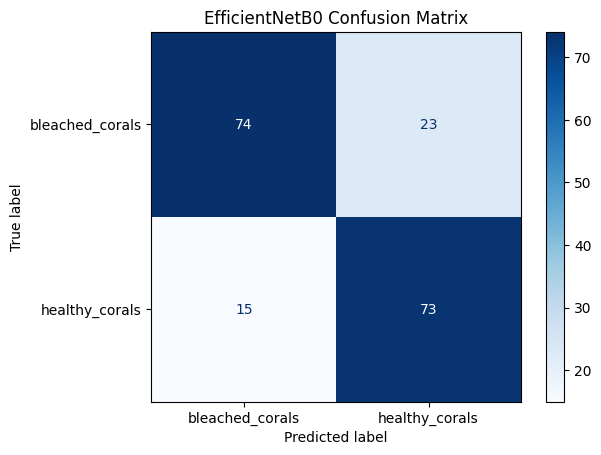


Classification Report for EfficientNetB0:
                 precision    recall  f1-score   support

bleached_corals       0.83      0.76      0.80        97
 healthy_corals       0.76      0.83      0.79        88

       accuracy                           0.79       185
      macro avg       0.80      0.80      0.79       185
   weighted avg       0.80      0.79      0.79       185



In [13]:
# ==============================================================
# 10. CONFUSION MATRIX & CLASSIFICATION REPORT
# ==============================================================
def evaluate_model(model, test_gen, model_name):
    y_true = test_gen.classes
    class_labels = list(test_gen.class_indices.keys())
    y_pred = (model.predict(test_gen) > 0.5).astype(int).flatten()
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(cmap='Blues')
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()
    print(f"\nClassification Report for {model_name}:")
    print(classification_report(y_true, y_pred, target_names=class_labels))
evaluate_model(model_resnet, test_gen_resnet, "ResNet50")
evaluate_model(model_effnet, test_gen_effnet, "EfficientNetB0")

6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step


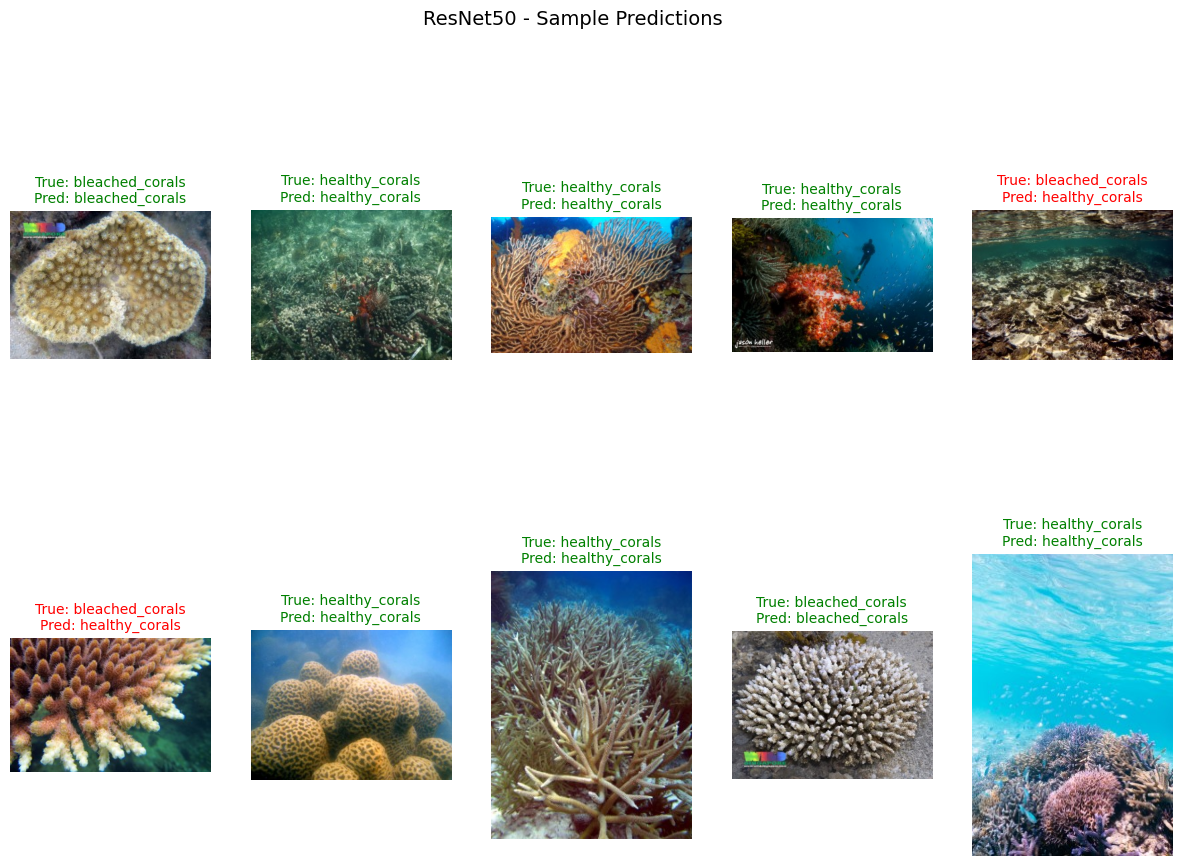

6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 776ms/step


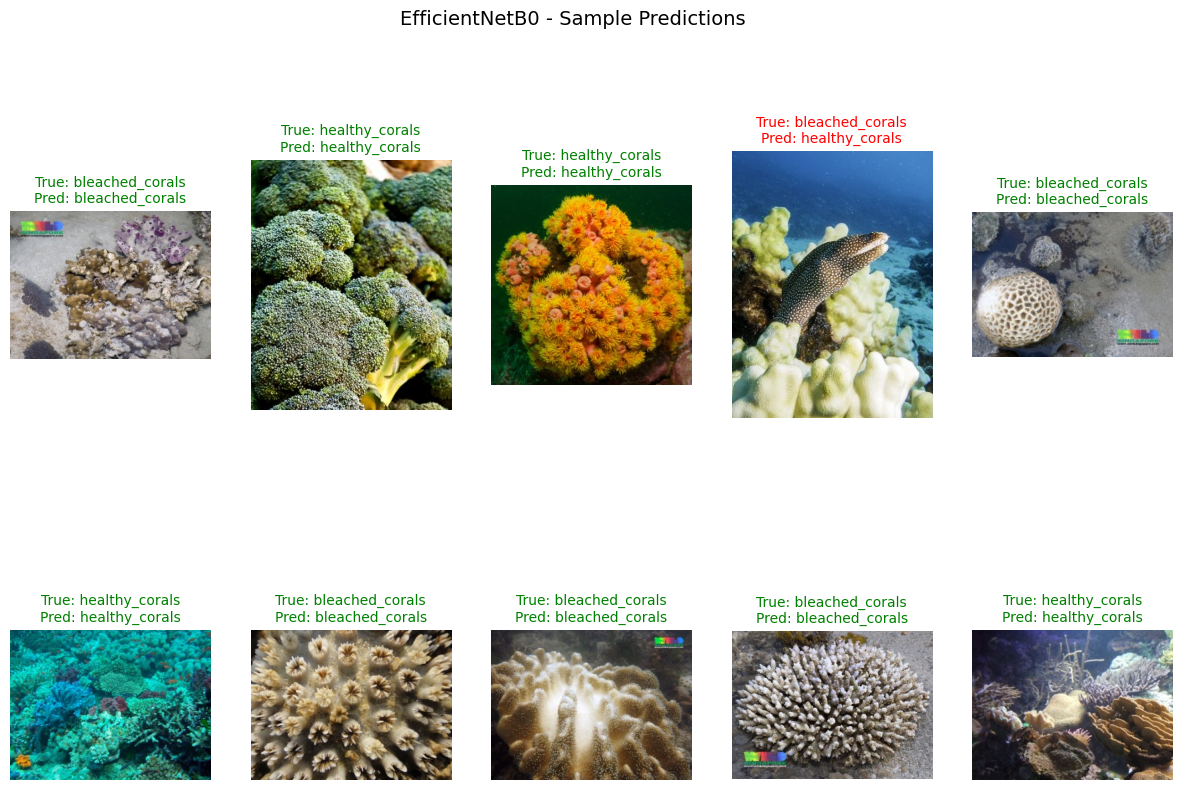

In [14]:
# ==============================================================
# 11. VISUALIZING SAMPLE PREDICTIONS
# ==============================================================

def show_predictions(model, test_gen, model_name, num_samples=10):
    # Get predictions
    test_gen.reset()
    preds = (model.predict(test_gen) > 0.5).astype(int).flatten()
    class_indices = {v: k for k, v in test_gen.class_indices.items()}

    # Collect filenames, true labels, and predicted labels
    filenames = test_gen.filenames
    true_labels = test_gen.classes
    pred_labels = preds

    # Pick random samples
    idxs = np.random.choice(range(len(filenames)), num_samples, replace=False)
    
    plt.figure(figsize=(15, 10))
    for i, idx in enumerate(idxs):
        img_path = os.path.join(test_gen.directory, filenames[idx])
        img = Image.open(img_path)
        true_label = class_indices[true_labels[idx]]
        pred_label = class_indices[pred_labels[idx]]

        plt.subplot(2, num_samples//2, i+1)
        plt.imshow(img)
        color = "green" if true_label == pred_label else "red"
        plt.title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=10)
        plt.axis("off")

    plt.suptitle(f"{model_name} - Sample Predictions", fontsize=14)
    plt.show()

# Show results for both models
show_predictions(model_resnet, test_gen_resnet, "ResNet50", num_samples=10)
show_predictions(model_effnet, test_gen_effnet, "EfficientNetB0", num_samples=10)